# Problem Definitinon

## Car Damage Severity Classification with my own CNN Architecture

## Problem Definition

### Learning Task
Learning task is to create a CNN model that can predict the damage of the car with its photo. It is divided into three categories major, minor and moderate

### Input Representation
The input that this model takes has the dimension of 224x224x3. So 3 input channels and each image will be resized to 224x224.

### Output
The output is a probability distribution over three classes using softmax function:
- Minor Damage
- Moderate Damage
- Severe Damage

### Type of Learning Task
This is a supervised image classification problem.

### Real World Relevance
Car damage severity detection can be useful for below applicatoins in real world:
- Insurance claim automation
- Vehicle inspection systems
- Accident analysis tools
- Faster claim settlement for customers

# Setup

In [1]:
 !pip install -q torch torchvision scikit-learn matplotlib seaborn tqdm

In [2]:
import os
from pathlib import Path
from collections import Counter
import time
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm

## Paths

In [3]:
DRIVE_DATA_DIR = "/content/drive/MyDrive/AA_DL_ETE/car_severity_dataset/data3a"
TRAIN_DIR = os.path.join(DRIVE_DATA_DIR, "training")
VAL_DIR = os.path.join(DRIVE_DATA_DIR, "validation")
os.listdir(DRIVE_DATA_DIR), os.listdir(TRAIN_DIR), os.listdir(VAL_DIR)


(['training', 'validation'],
 ['03-severe', '02-moderate', '01-minor'],
 ['02-moderate', '01-minor', '03-severe'])

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda


# Data Preprocessing and preparation

## Data Augmentation

In [5]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),  # small rotation only
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])


- I have applied data augmentation by techniques like cropping, flipping, rotation, color jitter, etc.,
- Each pixel is normalized to make the training more stable and faster
- validatoin daa is alos resized, cropped and normalized

## Loading the dataset and classes

In [6]:
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_ds   = datasets.ImageFolder(VAL_DIR, transform=val_transform)

classes = train_ds.classes
num_classes = len(classes)
print("Classes:", classes, "Num classes:", num_classes)
print("Train samples:", len(train_ds), "Val samples:", len(val_ds))

Classes: ['01-minor', '02-moderate', '03-severe'] Num classes: 3
Train samples: 1383 Val samples: 248


## Dataloader

In [19]:
BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


# Model Construction

## Model Architecture

In [9]:

def conv_block(in_ch, out_ch, kernel=3, stride=1, padding=1):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=kernel, stride=stride, padding=padding, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, kernel_size=kernel, stride=1, padding=padding, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

In [10]:
class DamageNet(nn.Module):
    def __init__(self, num_classes=3, dropout_p=0.5):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3, 32),    # -> 32 x 112 x 112
            conv_block(32, 64),   # -> 64 x 56 x 56
            conv_block(64, 128),  # -> 128 x 28 x 28
            conv_block(128, 256), # -> 256 x 14 x 14
            conv_block(256, 512), # -> 512 x 7 x 7
        )
        self.gap = nn.AdaptiveAvgPool2d(1)  # Global average pooling
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout_p),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p*0.5),
            nn.Linear(256, num_classes)
        )
        self._init_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

model = DamageNet(num_classes=num_classes).to(device)
print(model)



DamageNet(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inpl

### CNN Architecture Explanation

The model DamageNet is a custom Convolutional Neural Network designed to classify car damage severity.

The architecture consists of the following components:

1. Convolution Layers: Extract spatial features such as edges, textures, and shapes from images.

2. Batch Normalization: Stabilizes training and helps the network converge faster.

3. ReLU Activation: Introduces non-linearity so the model can learn complex patterns.

4. Pooling Layers: Reduce spatial dimensions and help the network focus on important features.

5. Fully Connected Layers: Convert extracted features into class predictions.

6. Dropout: Prevents overfitting by randomly disabling neurons during training.


## Loss functions and optimizers

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=3e-4)

The model is trained using Cross Entropy Loss, which is commonly used for multi-class classification problems.
It measures the difference between the predicted class probabilities and the actual class labels.

The optimizer used is Adam, Adam helps the model converge faster while also reducing the risk of overfitting.

# Training Loop & Validatoin/Performance Evaluation

In [13]:
# 10) Training loop with detailed printing
NUM_EPOCHS = 40
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
early_stop_patience = 6
no_improve_epochs = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

total_start = time.time()
for epoch in range(1, NUM_EPOCHS+1):
    epoch_start = time.time()
    # --- training ---
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    # iterate batches and print batch-level loss (like your logs)
    for batch_idx, (inputs, labels) in enumerate(train_loader, start=1):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        # stats
        batch_loss = loss.item()
        running_loss += batch_loss * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels).item()
        total_samples += labels.size(0)

        # Print every batch (like your logs)
        print(f"Epoch: {epoch}/{NUM_EPOCHS} | Batch: {batch_idx}/{len(train_loader)} | Batch Loss: {batch_loss:.4f}")

    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = running_corrects / total_samples * 100.0
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    # --- validation ---
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    val_total = 0

    with torch.no_grad():
        for v_batch_idx, (v_inputs, v_labels) in enumerate(val_loader, start=1):
            v_inputs = v_inputs.to(device, non_blocking=True)
            v_labels = v_labels.to(device, non_blocking=True)
            with torch.cuda.amp.autocast():
                v_outputs = model(v_inputs)
                v_loss = criterion(v_outputs, v_labels)

            val_running_loss += v_loss.item() * v_inputs.size(0)
            _, v_preds = torch.max(v_outputs, 1)
            val_running_corrects += torch.sum(v_preds == v_labels).item()
            val_total += v_labels.size(0)
            # optional per-batch print for validation:
            print(f"Val Epoch: {epoch}/{NUM_EPOCHS} | Batch: {v_batch_idx}/{len(val_loader)} | Batch Loss: {v_loss.item():.4f}")

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_running_corrects / val_total * 100.0
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    # print epoch summary (train + val accuracy)
    print(f"--- Epoch {epoch}/{NUM_EPOCHS} SUMMARY ---")
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
    print(f" Val Loss: {epoch_val_loss:.4f} |  Val Acc: {epoch_val_acc:.2f}%")
    epoch_time = time.time() - epoch_start
    print(f"Epoch time: {epoch_time:.1f}s\n")

    # save best
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_damage_model.pth")
        print(f"Best model saved with val acc: {best_val_acc:.2f}%")
        no_improve_epochs = 0
    else:
        no_improve_epochs += 1

    # early stopping
    if no_improve_epochs >= early_stop_patience:
        print(f"Early stopping: no improvement for {early_stop_patience} epochs")
        break

total_time = time.time() - total_start
print("Training complete in {:.1f}m".format(total_time/60))
print("Best val acc: {:.2f}%".format(best_val_acc))

# load best weights back
model.load_state_dict(best_model_wts)


/tmp/ipykernel_672/3597930853.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch: 1/40 | Batch: 1/44 | Batch Loss: 1.8241
Epoch: 1/40 | Batch: 2/44 | Batch Loss: 1.4178
Epoch: 1/40 | Batch: 3/44 | Batch Loss: 1.3341
Epoch: 1/40 | Batch: 4/44 | Batch Loss: 1.6528
Epoch: 1/40 | Batch: 5/44 | Batch Loss: 2.0000
Epoch: 1/40 | Batch: 6/44 | Batch Loss: 1.6354
Epoch: 1/40 | Batch: 7/44 | Batch Loss: 1.4331
Epoch: 1/40 | Batch: 8/44 | Batch Loss: 1.0066
Epoch: 1/40 | Batch: 9/44 | Batch Loss: 1.5104
Epoch: 1/40 | Batch: 10/44 | Batch Loss: 1.3203
Epoch: 1/40 | Batch: 11/44 | Batch Loss: 1.1878
Epoch: 1/40 | Batch: 12/44 | Batch Loss: 1.1757
Epoch: 1/40 | Batch: 13/44 | Batch Loss: 1.2625
Epoch: 1/40 | Batch: 14/44 | Batch Loss: 1.2948
Epoch: 1/40 | Batch: 15/44 | Batch Loss: 1.2116
Epoch: 1/40 | Batch: 16/44 | Batch Loss: 1.1841
Epoch: 1/40 | Batch: 17/44 | Batch Loss: 1.1770
Epoch: 1/40 | Batch: 18/44 | Batch Loss: 0.9197
Epoch: 1/40 | Batch: 19/44 | Batch Loss: 1.0588
Epoch: 1/40 | Batch: 20/44 | Batch Loss: 1.4301
Epoch: 1/40 | Batch: 21/44 | Batch Loss: 1.2691
E

/tmp/ipykernel_672/3597930853.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Val Epoch: 1/40 | Batch: 1/8 | Batch Loss: 1.3398
Val Epoch: 1/40 | Batch: 2/8 | Batch Loss: 0.9837
Val Epoch: 1/40 | Batch: 3/8 | Batch Loss: 0.8938
Val Epoch: 1/40 | Batch: 4/8 | Batch Loss: 1.4042
Val Epoch: 1/40 | Batch: 5/8 | Batch Loss: 1.0774
Val Epoch: 1/40 | Batch: 6/8 | Batch Loss: 0.5732
Val Epoch: 1/40 | Batch: 7/8 | Batch Loss: 0.5971
Val Epoch: 1/40 | Batch: 8/8 | Batch Loss: 0.5110
--- Epoch 1/40 SUMMARY ---
Train Loss: 1.2660 | Train Acc: 43.46%
 Val Loss: 0.9358 |  Val Acc: 54.03%
Epoch time: 207.9s

Best model saved with val acc: 54.03%
Epoch: 2/40 | Batch: 1/44 | Batch Loss: 1.1503
Epoch: 2/40 | Batch: 2/44 | Batch Loss: 1.0001
Epoch: 2/40 | Batch: 3/44 | Batch Loss: 1.5739
Epoch: 2/40 | Batch: 4/44 | Batch Loss: 0.7968
Epoch: 2/40 | Batch: 5/44 | Batch Loss: 1.1629
Epoch: 2/40 | Batch: 6/44 | Batch Loss: 0.9375
Epoch: 2/40 | Batch: 7/44 | Batch Loss: 0.9288
Epoch: 2/40 | Batch: 8/44 | Batch Loss: 0.9719
Epoch: 2/40 | Batch: 9/44 | Batch Loss: 1.0021
Epoch: 2/40 | Ba

<All keys matched successfully>

### Training Process

The training loop runs for multiple epochs. During each epoch:

1. The model processes batches of training images.
2. Predictions are generated by the CNN.
3. The loss between predicted and actual labels is calculated.
4. Backpropagation is used to update the model weights.
5. Accuracy and loss values are recorded.

After each epoch, the model is also evaluated on the validation dataset.
This helps monitor whether the model is learning effectively or starting to overfit.

# Analysis and interpretation of model outputs

## Accuracy and loss graphs

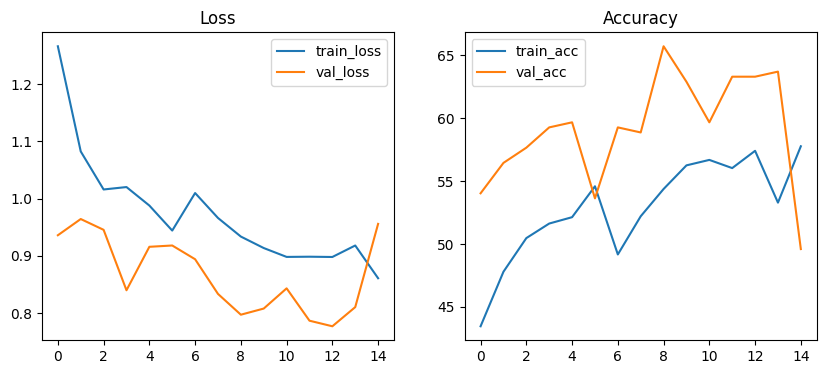

In [14]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='train_loss')
plt.plot(val_losses, label='val_loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(train_accs, label='train_acc')
plt.plot(val_accs, label='val_acc')
plt.legend()
plt.title('Accuracy')
plt.show()

## Evaluation Metrics

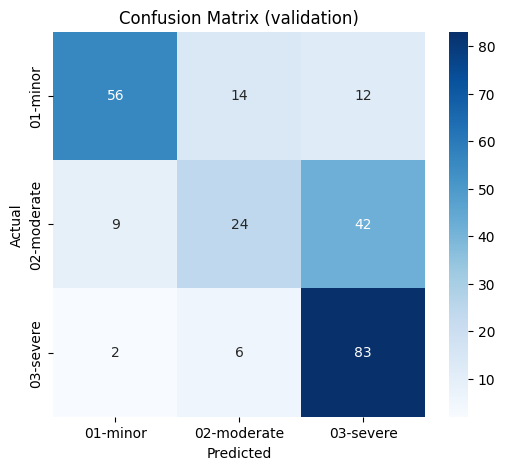

              precision    recall  f1-score   support

    01-minor     0.8358    0.6829    0.7517        82
 02-moderate     0.5455    0.3200    0.4034        75
   03-severe     0.6058    0.9121    0.7281        91

    accuracy                         0.6573       248
   macro avg     0.6624    0.6383    0.6277       248
weighted avg     0.6636    0.6573    0.6377       248



In [15]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (validation)')
plt.show()

print(classification_report(all_labels, all_preds, target_names=classes, digits=4))


## Overall Interpretation

- The training loss gradually decreases during training, which shows that the model is learning patterns from the training data.

- The validation loss also decreases initially but fluctuates in later epochs. This indicates that the model has some difficulty generalizing consistently to unseen data.

- Training accuracy increases from around 43% to about 57%, showing that the model improves its predictions on the training dataset over time.

- Validation accuracy reaches a maximum of about 65% but later drops to around 50%. This instability suggests that the model performance varies depending on the validation samples.

- Early stopping was triggered because the validation accuracy did not improve for several epochs. This prevents unnecessary training and helps avoid overfitting.

- The confusion matrix shows that the model performs best on the severe damage class, correctly predicting most of those samples.

- The minor damage class is predicted reasonably well but some samples are confused with moderate and severe damage.

- The moderate damage class shows the highest confusion, with many samples predicted as severe damage. This suggests that the visual differences between moderate and severe damage are sometimes difficult for the model to distinguish.

- The overall best validation accuracy achieved by the model is about 65%, which indicates moderate performance.

- The relatively low accuracy may be due to limited dataset size, visual similarity between damage categories, and training the CNN from scratch without using pretrained models.

- Performance could be improved by increasing dataset size, applying stronger data augmentation, or using transfer learning with pretrained CNN architectures.

# Saving the model for the UI part

In [18]:
torch.save(model.state_dict(),"/content/drive/MyDrive/AA_DL_ETE/imporved_damage_model.pth")